In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

In [3]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


# Hold-Out Approach
## train test split

In [4]:
X=df.iloc[:,0:-1]
y=df.iloc[:,-1]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [7]:
# create a linear regression model
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [8]:
# mse of the model on test set

mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [9]:
mse

18.49542012244853

In [10]:
r2

0.7789207451814402

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [12]:
# Load the Auto MPG dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']
auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')


C:\Users\USER\AppData\Local\Temp\ipykernel_11136\2354536740.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')


In [13]:

# Drop rows with missing values
auto_mpg = auto_mpg.dropna()

In [14]:
# Define features and target
features = auto_mpg[['Horsepower']]  # Only use 'Horsepower' as a feature
target = auto_mpg['MPG']

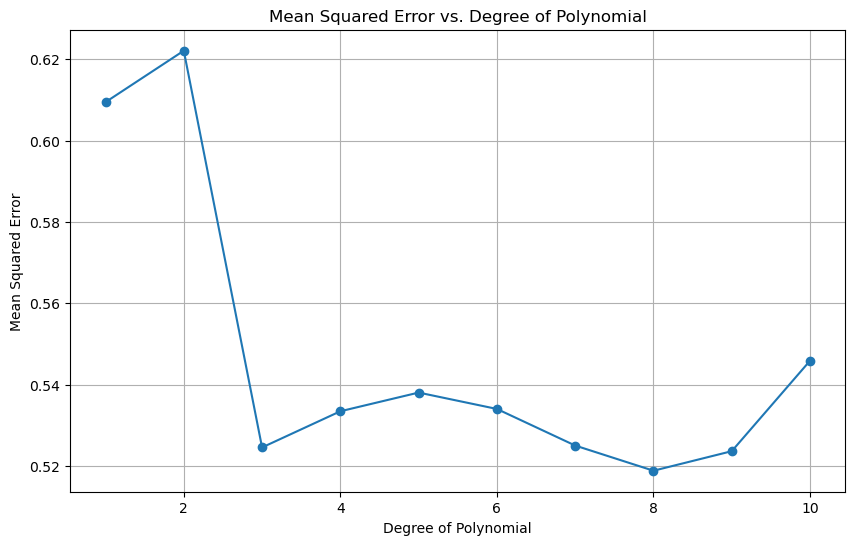

In [16]:
# List of polynomial degrees
degrees = list(range(1, 11))  # Extend degrees to 10

# Split the dataset into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=4)

# List to store Mean Squared Errors
mse_list = []

for degree in degrees:
    # Add polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create a linear regression model
    model = LinearRegression()

    # Train the model on the polynomial features training data
    model.fit(X_train_poly, y_train)

    # Use the trained model to predict the target values in the test set
    y_pred = model.predict(X_test_poly)

    # Calculate the Mean Squared Error of the model on the test set
    mse = mean_squared_error(y_test, y_pred)

    # Store the Mean Squared Error in the list
    mse_list.append(mse)

# Plot the Mean Squared Error as a function of the degree of the polynomial
plt.figure(figsize=(10, 6))
plt.plot(degrees, mse_list, marker='o')
plt.title('Mean Squared Error vs. Degree of Polynomial')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()
